# Tech Challenge Fase 3: EDA complementar do enriquecimento educacional

## Censo Escolar desenvolvimento 2023

Este notebook avalia **exclusivamente as novas features educacionais** adicionadas à
`base_modelagem/v2`.

A EDA original (`01_eda.ipynb`) continua válida para target, território, rede e
variáveis socioeconômicas. Aqui o objetivo é responder, antes de alterar o
pré-processamento e os modelos:

- quais features educacionais têm boa cobertura;
- quais possuem forte assimetria e podem exigir transformação;
- quais apresentam valores extremos;
- quais são redundantes entre si;
- quais apresentam associação exploratória com o target;
- quais transformações devem ser consideradas na pipeline.

### Regra de desenvolvimento

**Somente 2023 é carregado neste notebook.**

O snapshot de 2024 permanece reservado para a avaliação temporal final e não é
usado para selecionar features, transformações, modelos, hiperparâmetros ou
thresholds.

> As associações observadas são exploratórias e não devem ser interpretadas como
> relações causais.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
ANO_DESENVOLVIMENTO = 2023


In [2]:
def encontrar_raiz_projeto():
    atual = Path.cwd().resolve()

    for pasta in [atual] + list(atual.parents):
        if (pasta / "requirements.txt").exists():
            return pasta

    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto. "
        "Execute o notebook dentro do repositório."
    )


PROJECT_ROOT = encontrar_raiz_projeto()

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "modeling"
    / "base_modelagem"
    / "v2"
    / "ano=2023"
)

IMAGES_PATH = (
    PROJECT_ROOT
    / "images"
    / "eda_enrichment"
)

REPORTS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "metrics"
)

IMAGES_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print(f"Raiz do projeto: {PROJECT_ROOT}")
print(f"Dados 2023: {DATA_PATH}")
print(f"Imagens: {IMAGES_PATH}")
print(f"Relatórios: {REPORTS_PATH}")


Raiz do projeto: C:\Users\camil\Documents\FIAP\Fase 3\fiap-tech-challenge-fase3
Dados 2023: C:\Users\camil\Documents\FIAP\Fase 3\fiap-tech-challenge-fase3\data\modeling\base_modelagem\v2\ano=2023
Imagens: C:\Users\camil\Documents\FIAP\Fase 3\fiap-tech-challenge-fase3\images\eda_enrichment
Relatórios: C:\Users\camil\Documents\FIAP\Fase 3\fiap-tech-challenge-fase3\reports\metrics


## 1. Features avaliadas

As 11 features abaixo foram construídas a partir do Censo Escolar do ano anterior
ao target, agregadas por município e rede de ensino.

As features são divididas em três grupos analíticos:

- **escala da oferta**: quantidade de escolas, matrículas, docentes e turmas;
- **infraestrutura e contexto**: ruralidade, internet, biblioteca e laboratório;
- **razões educacionais**: alunos por turma, matrículas por docente e proporção de
  matrículas em tempo integral.

Nenhuma transformação é aplicada neste momento.


In [3]:
FEATURES_ESCALA = [
    "quantidade_escolas_anos_iniciais",
    "total_matriculas_anos_iniciais",
    "total_docentes_anos_iniciais",
    "total_turmas_anos_iniciais",
]

FEATURES_PROPORCAO = [
    "proporcao_escolas_rurais",
    "proporcao_internet_aprendizagem",
    "proporcao_biblioteca_sala_leitura",
    "proporcao_laboratorio_informatica",
    "proporcao_matriculas_integral_anos_iniciais",
]

FEATURES_RAZAO = [
    "alunos_por_turma_anos_iniciais",
    "razao_matriculas_docentes_anos_iniciais",
]

FEATURES_EDUCACIONAIS = (
    FEATURES_ESCALA
    + FEATURES_PROPORCAO
    + FEATURES_RAZAO
)

COLUNAS_LEITURA = [
    "ano",
    "aluno_key",
    "id_municipio",
    "alfabetizado",
    "rede_nome",
    "regiao",
] + FEATURES_EDUCACIONAIS

print("Features educacionais:", len(FEATURES_EDUCACIONAIS))
display(pd.Series(FEATURES_EDUCACIONAIS, name="feature").to_frame())


Features educacionais: 11


,feature
0,quantidade_escolas_anos_iniciais
1,total_matriculas_anos_iniciais
2,total_docentes_anos_iniciais
3,total_turmas_anos_iniciais
4,proporcao_escolas_rurais
5,proporcao_internet_aprendizagem
6,proporcao_biblioteca_sala_leitura
7,proporcao_laboratorio_informatica
8,proporcao_matriculas_integral_anos_iniciais
9,alunos_por_turma_anos_iniciais


## 2. Carregamento local somente 2023

A leitura utiliza apenas as colunas necessárias, reduzindo memória e tempo de
execução. O notebook falha se encontrar qualquer ano diferente de 2023.


In [4]:
def carregar_2023():
    arquivos = sorted(DATA_PATH.glob("*.parquet"))

    if not arquivos:
        raise FileNotFoundError(
            f"Nenhum Parquet encontrado em: {DATA_PATH}"
        )

    partes = [
        pd.read_parquet(
            arquivo,
            columns=COLUNAS_LEITURA,
        )
        for arquivo in arquivos
    ]

    return pd.concat(
        partes,
        ignore_index=True,
    )


df = carregar_2023()

anos = sorted(
    df["ano"]
    .dropna()
    .unique()
    .tolist()
)

assert anos == [ANO_DESENVOLVIMENTO], (
    "Este notebook deve utilizar exclusivamente 2023. "
    f"Anos encontrados: {anos}"
)

assert len(df) == 1_502_809
assert df["aluno_key"].nunique() == 1_502_809
assert int((df["alfabetizado"] == 0).sum()) == 625_382
assert int((df["alfabetizado"] == 1).sum()) == 877_427

print("✓ Base 2023 carregada e reconciliada.")
print(f"Linhas: {len(df):,}")
print(f"Municípios: {df['id_municipio'].nunique():,}")
print(f"Features educacionais: {len(FEATURES_EDUCACIONAIS)}")


✓ Base 2023 carregada e reconciliada.
Linhas: 1,502,809
Municípios: 4,871
Features educacionais: 11


## 3. Construção do nível município-rede

As features educacionais são contextuais: alunos do mesmo município e rede recebem
o mesmo contexto do Censo Escolar.

Por isso, parte da EDA é feita no nível **município + rede**, evitando que municípios
com muitos alunos dominem artificialmente análises de distribuição e correlação entre
as features.

A associação com o target é analisada de duas formas:

1. no nível do aluno, refletindo o conjunto efetivamente visto pelo modelo;
2. no nível município-rede, para observar relações entre contexto e taxa de alfabetização.


In [5]:
# Auditoria: dentro de um município-rede, cada feature contextual deve
# ter no máximo um valor não nulo distinto.

consistencia = []

for feature in FEATURES_EDUCACIONAIS:
    max_distintos = (
        df.groupby(
            ["id_municipio", "rede_nome"],
            observed=True,
        )[feature]
        .nunique(dropna=False)
        .max()
    )

    consistencia.append(
        {
            "feature": feature,
            "max_valores_distintos_no_contexto": int(max_distintos),
        }
    )

df_consistencia = pd.DataFrame(consistencia)

display(df_consistencia)

assert (
    df_consistencia["max_valores_distintos_no_contexto"] <= 1
).all(), (
    "Há feature educacional variando dentro da mesma chave município-rede."
)

print("✓ Features contextuais consistentes por município-rede.")


,feature,max_valores_distintos_no_contexto
0,quantidade_escolas_anos_iniciais,1
1,total_matriculas_anos_iniciais,1
2,total_docentes_anos_iniciais,1
3,total_turmas_anos_iniciais,1
4,proporcao_escolas_rurais,1
5,proporcao_internet_aprendizagem,1
6,proporcao_biblioteca_sala_leitura,1
7,proporcao_laboratorio_informatica,1
8,proporcao_matriculas_integral_anos_iniciais,1
9,alunos_por_turma_anos_iniciais,1


✓ Features contextuais consistentes por município-rede.


In [6]:
agregacoes = {
    "quantidade_alunos": ("alfabetizado", "size"),
    "quantidade_alfabetizados": ("alfabetizado", "sum"),
}

for feature in FEATURES_EDUCACIONAIS:
    agregacoes[feature] = (feature, "first")

df_contexto = (
    df.groupby(
        [
            "id_municipio",
            "rede_nome",
            "regiao",
        ],
        observed=True,
        as_index=False,
    )
    .agg(**agregacoes)
)

df_contexto["quantidade_nao_alfabetizados"] = (
    df_contexto["quantidade_alunos"]
    - df_contexto["quantidade_alfabetizados"]
)

df_contexto["taxa_alfabetizacao"] = (
    df_contexto["quantidade_alfabetizados"]
    / df_contexto["quantidade_alunos"]
)

print(f"Contextos município-rede: {len(df_contexto):,}")
display(df_contexto.head())


Contextos município-rede: 5,881


,id_municipio,rede_nome,regiao,quantidade_alunos,quantidade_alfabetizados,quantidade_escolas_anos_iniciais,total_matriculas_anos_iniciais,total_docentes_anos_iniciais,total_turmas_anos_iniciais,proporcao_escolas_rurais,proporcao_internet_aprendizagem,proporcao_biblioteca_sala_leitura,proporcao_laboratorio_informatica,proporcao_matriculas_integral_anos_iniciais,alunos_por_turma_anos_iniciais,razao_matriculas_docentes_anos_iniciais,quantidade_nao_alfabetizados,taxa_alfabetizacao
0,1100015,Municipal,Norte,227,153,15.0000,"1,363.0000",61.0000,59.0000,0.4667,0.3333,0.4000,0.0000,0.0000,23.1017,22.3443,74,0.6740
1,1100023,Municipal,Norte,1222,764,22.0000,"5,885.0000",259.0000,244.0000,0.3182,0.8182,0.8182,0.9545,0.1344,24.1189,22.7220,458,0.6252
2,1100031,Municipal,Norte,76,54,3.0000,358.0000,28.0000,26.0000,0.0000,0.0000,0.3333,0.3333,0.0000,13.7692,12.7857,22,0.7105
3,1100049,Estadual,Norte,200,132,15.0000,"1,457.0000",72.0000,64.0000,0.5333,1.0000,0.5333,0.4667,0.0000,22.7656,20.2361,68,0.6600
4,1100049,Municipal,Norte,613,385,18.0000,"2,915.0000",160.0000,152.0000,0.5556,0.7778,0.5000,0.1667,0.0343,19.1776,18.2188,228,0.6281


## 4. Missingness das novas features

Os nulos não serão preenchidos neste notebook.

A imputação continuará sendo responsabilidade da pipeline de Machine Learning, para
que as estatísticas de imputação sejam aprendidas somente nos dados de treino.


In [7]:
missing = pd.DataFrame(
    {
        "feature": FEATURES_EDUCACIONAIS,
        "nulos_alunos": [
            int(df[col].isna().sum())
            for col in FEATURES_EDUCACIONAIS
        ],
        "nulos_contextos": [
            int(df_contexto[col].isna().sum())
            for col in FEATURES_EDUCACIONAIS
        ],
    }
)

missing["pct_nulos_alunos"] = (
    100 * missing["nulos_alunos"] / len(df)
)

missing["pct_nulos_contextos"] = (
    100 * missing["nulos_contextos"] / len(df_contexto)
)

missing = missing.sort_values(
    "pct_nulos_alunos",
    ascending=False,
)

display(missing)

missing.to_csv(
    REPORTS_PATH / "eda_enrichment_2023_missingness.csv",
    index=False,
)


,feature,nulos_alunos,nulos_contextos,pct_nulos_alunos,pct_nulos_contextos
9,alunos_por_turma_anos_iniciais,86,6,0.0057,0.1020
10,razao_matriculas_docentes_anos_iniciais,86,6,0.0057,0.1020
0,quantidade_escolas_anos_iniciais,75,4,0.0050,0.0680
1,total_matriculas_anos_iniciais,75,4,0.0050,0.0680
2,total_docentes_anos_iniciais,75,4,0.0050,0.0680
3,total_turmas_anos_iniciais,75,4,0.0050,0.0680
4,proporcao_escolas_rurais,75,4,0.0050,0.0680
5,proporcao_internet_aprendizagem,75,4,0.0050,0.0680
6,proporcao_biblioteca_sala_leitura,75,4,0.0050,0.0680
7,proporcao_laboratorio_informatica,75,4,0.0050,0.0680


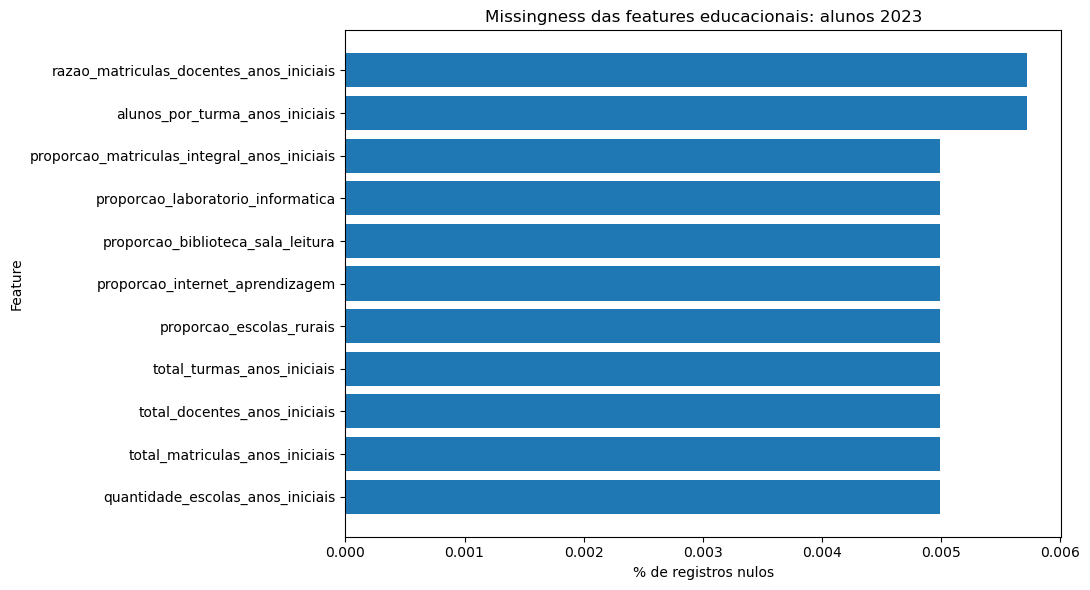

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))

plot_missing = missing.sort_values(
    "pct_nulos_alunos",
    ascending=True,
)

ax.barh(
    plot_missing["feature"],
    plot_missing["pct_nulos_alunos"],
)

ax.set_title(
    "Missingness das features educacionais: alunos 2023"
)
ax.set_xlabel("% de registros nulos")
ax.set_ylabel("Feature")

fig.tight_layout()

fig.savefig(
    IMAGES_PATH / "01_missingness_educacional_2023.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()


## 5. Estatísticas descritivas, assimetria e outliers

A análise abaixo é feita no nível município-rede.

Para features não negativas também calculamos a assimetria após `log1p`. Isso **não
significa que a transformação será adotada automaticamente**; serve apenas como
evidência para a decisão posterior do pré-processamento.


In [9]:
def estatisticas_feature(serie):
    s = serie.dropna().astype(float)

    if s.empty:
        return {}

    quantis = s.quantile(
        [
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )

    resultado = {
        "n": int(s.size),
        "n_unique": int(s.nunique()),
        "min": float(s.min()),
        "p01": float(quantis.loc[0.01]),
        "p05": float(quantis.loc[0.05]),
        "p25": float(quantis.loc[0.25]),
        "p50": float(quantis.loc[0.50]),
        "p75": float(quantis.loc[0.75]),
        "p95": float(quantis.loc[0.95]),
        "p99": float(quantis.loc[0.99]),
        "max": float(s.max()),
        "mean": float(s.mean()),
        "std": float(s.std()),
        "skew_raw": float(s.skew()),
    }

    if (s >= 0).all():
        log_s = np.log1p(s)

        resultado["skew_log1p"] = float(
            pd.Series(log_s).skew()
        )

        resultado["reducao_abs_skew_log1p"] = (
            abs(resultado["skew_raw"])
            - abs(resultado["skew_log1p"])
        )

    else:
        resultado["skew_log1p"] = np.nan
        resultado["reducao_abs_skew_log1p"] = np.nan

    return resultado


linhas = []

for feature in FEATURES_EDUCACIONAIS:
    linha = {
        "feature": feature,
        **estatisticas_feature(
            df_contexto[feature]
        ),
    }

    linhas.append(linha)

descritivas = pd.DataFrame(linhas)

descritivas["candidata_log1p_distribuicao"] = (
    (descritivas["skew_raw"].abs() >= 1.0)
    & (
        descritivas["skew_log1p"].abs()
        < descritivas["skew_raw"].abs()
    )
)

display(
    descritivas.sort_values(
        "skew_raw",
        key=lambda s: s.abs(),
        ascending=False,
    )
)

descritivas.to_csv(
    REPORTS_PATH / "eda_enrichment_2023_descritivas.csv",
    index=False,
)


,feature,n,n_unique,min,p01,p05,p25,p50,p75,p95,p99,max,mean,std,skew_raw,skew_log1p,reducao_abs_skew_log1p,candidata_log1p_distribuicao
1,total_matriculas_anos_iniciais,5877,2368,29.0000,61.7600,105.0000,265.0000,581.0000,"1,344.0000","5,078.6000","16,224.6000","263,015.0000","1,540.6078","5,279.9069",26.2937,0.5050,25.7887,True
2,total_docentes_anos_iniciais,5877,493,0.0000,5.0000,8.0000,18.0000,36.0000,77.0000,258.2000,799.6800,"11,349.0000",83.1358,243.8536,22.5881,0.6301,21.9579,True
3,total_turmas_anos_iniciais,5877,431,0.0000,5.0000,6.0000,15.0000,29.0000,63.0000,218.0000,653.9200,"9,361.0000",68.5818,201.4620,22.5876,0.6265,21.9611,True
0,quantidade_escolas_anos_iniciais,5877,137,1.0000,1.0000,1.0000,2.0000,5.0000,13.0000,44.0000,98.0000,790.0000,12.0556,22.3886,11.0782,0.6206,10.4576,True
8,proporcao_matriculas_integral_anos_iniciais,5877,3512,0.0000,0.0000,0.0000,0.0000,0.0162,0.1261,0.8712,1.0000,1.0000,0.1354,0.2567,2.2985,2.0377,0.2608,True
9,alunos_por_turma_anos_iniciais,5875,4013,3.6842,9.7232,12.7778,17.1547,20.1200,23.0543,27.5000,33.7648,80.0000,20.2472,4.9340,1.1897,-0.5478,0.6419,True
10,razao_matriculas_docentes_anos_iniciais,5875,4461,3.6842,6.5695,8.8869,13.0000,16.2958,20.2796,26.7577,33.1785,58.8571,16.9562,5.7137,0.9410,-0.2456,0.6954,False
7,proporcao_laboratorio_informatica,5877,644,0.0000,0.0000,0.0000,0.0000,0.2500,0.7500,1.0000,1.0000,1.0000,0.3866,0.3872,0.5219,0.3470,0.1749,False
5,proporcao_internet_aprendizagem,5877,812,0.0000,0.0000,0.0000,0.2778,0.6667,1.0000,1.0000,1.0000,1.0000,0.6054,0.3700,-0.3632,-0.5705,-0.2072,False
6,proporcao_biblioteca_sala_leitura,5877,784,0.0000,0.0000,0.0000,0.2500,0.6000,1.0000,1.0000,1.0000,1.0000,0.5852,0.3649,-0.2067,-0.4121,-0.2053,False


### Visualização das distribuições

Para evitar que poucos extremos comprimam completamente os histogramas, os gráficos
são limitados visualmente entre P1 e P99.

**Nenhum valor é removido ou alterado nos dados.** O recorte ocorre apenas no eixo
da visualização.


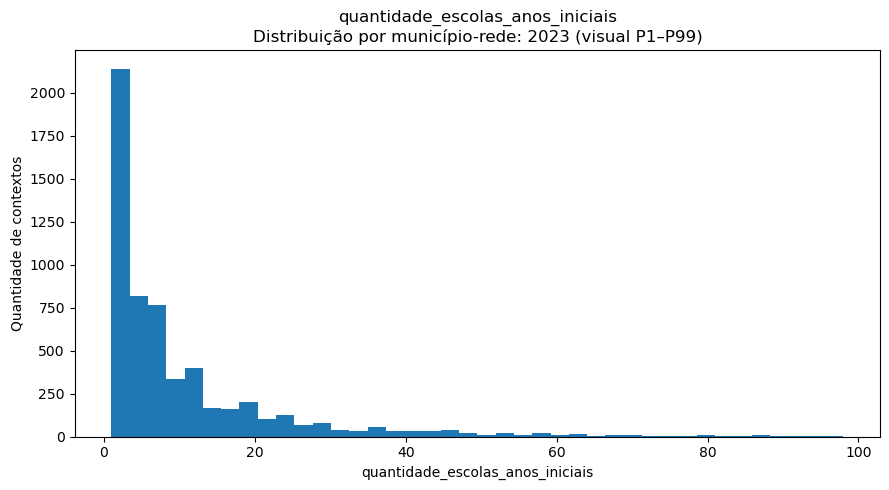

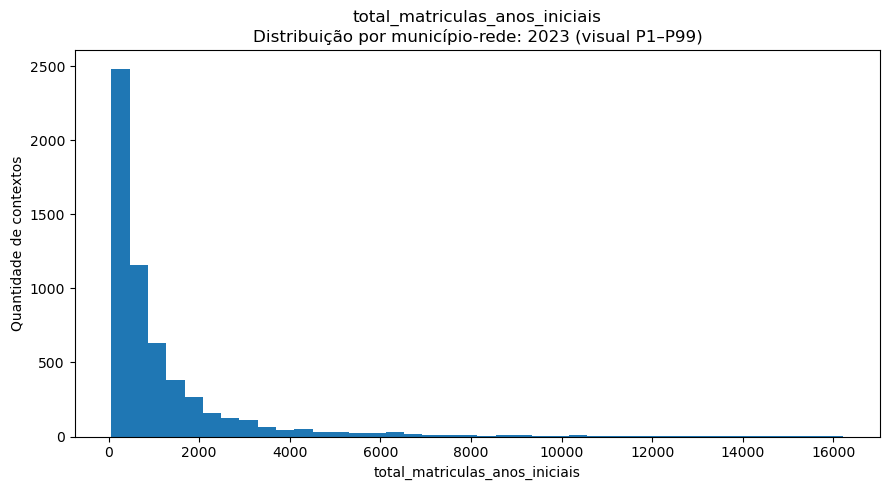

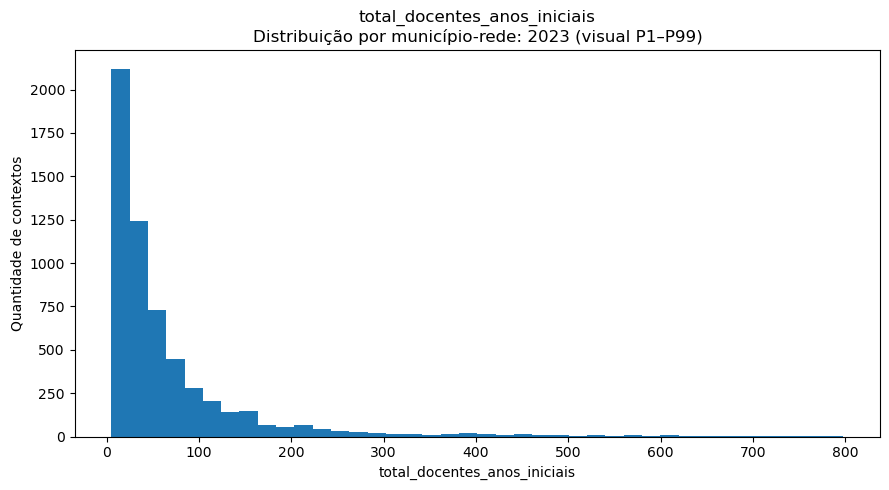

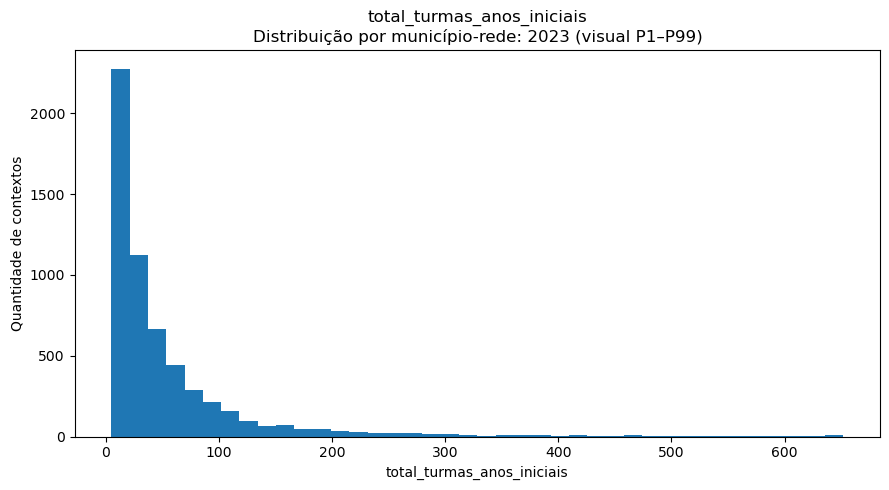

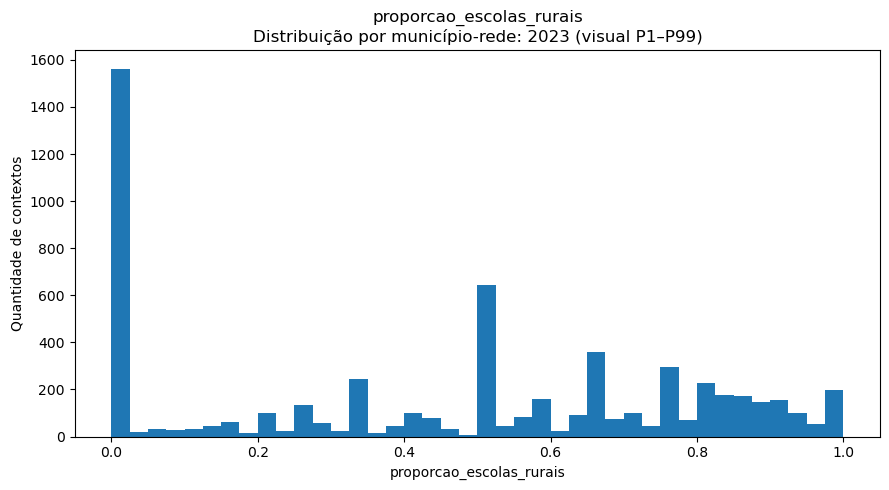

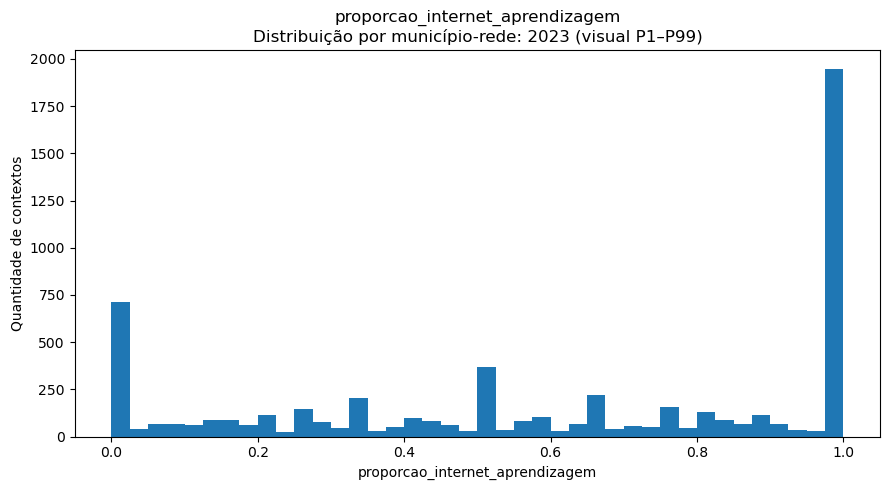

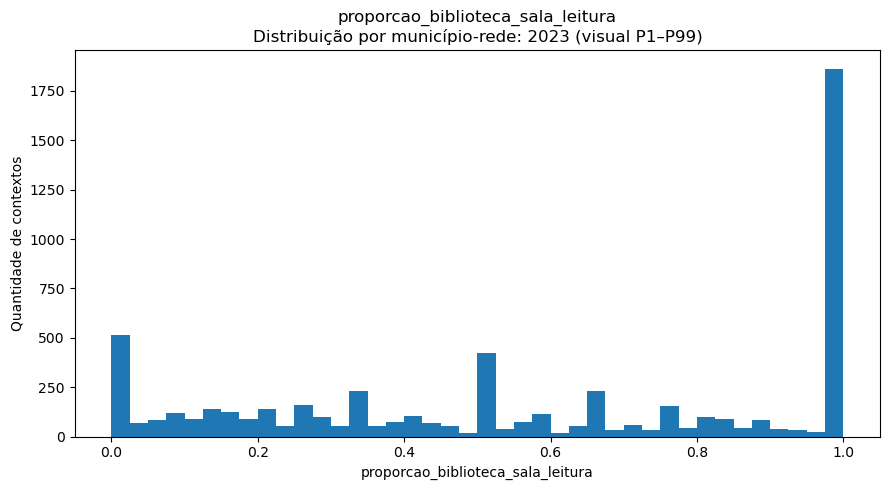

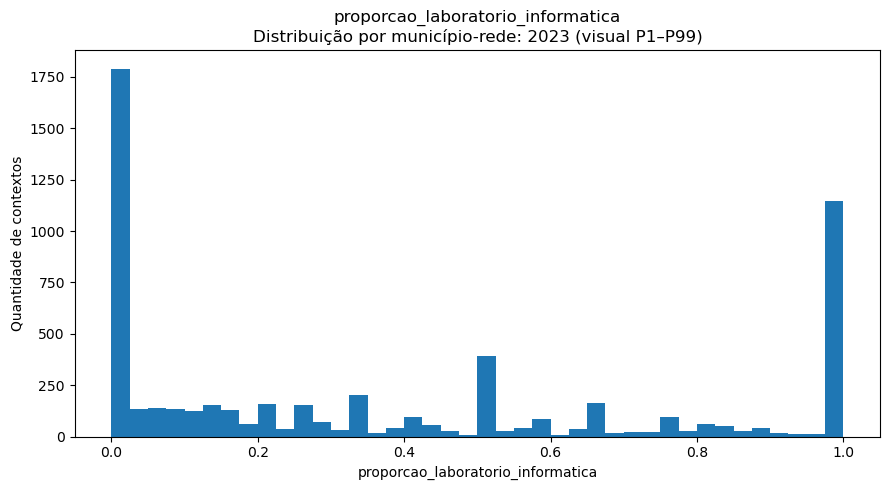

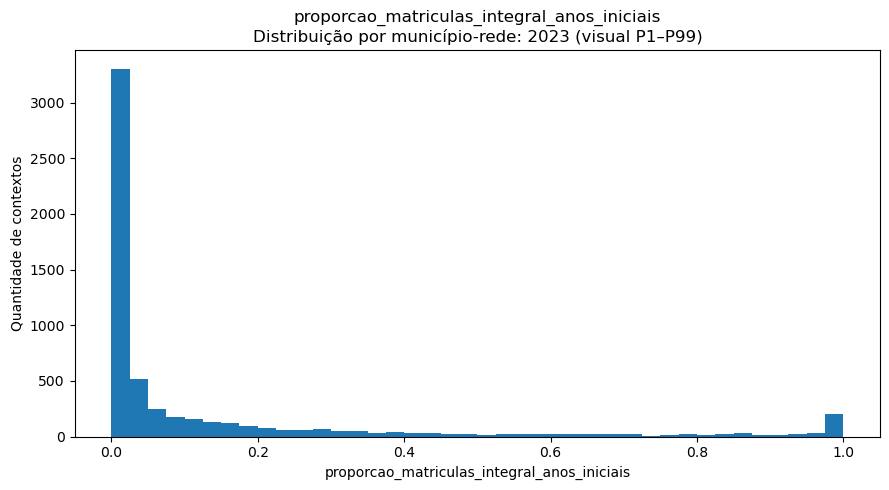

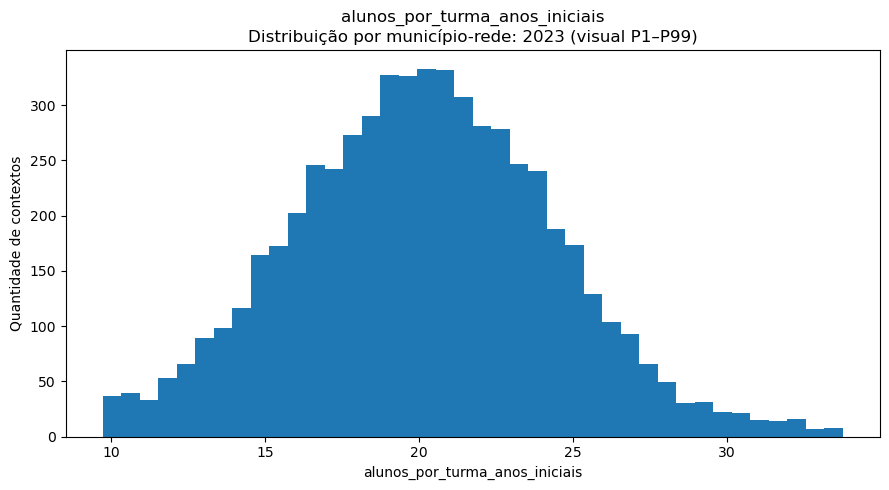

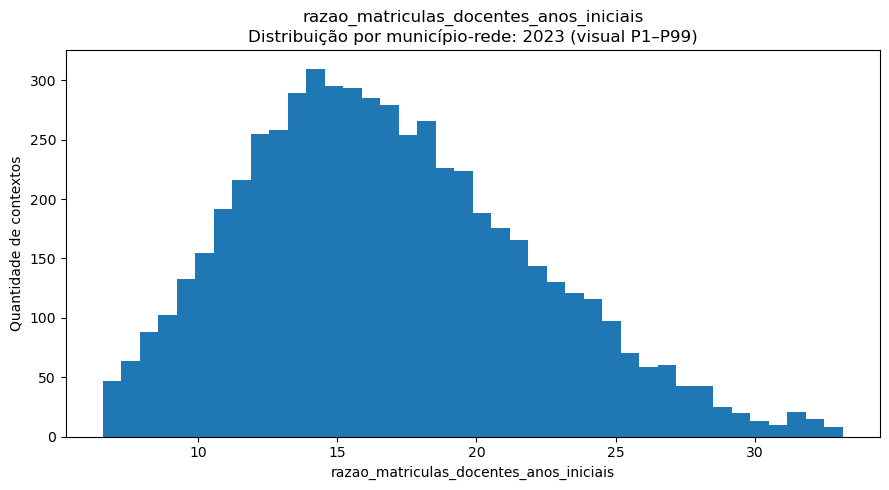

In [10]:
def salvar_histograma_contexto(
    feature,
    indice,
):
    s = (
        df_contexto[feature]
        .dropna()
        .astype(float)
    )

    if s.empty:
        return

    p01 = s.quantile(0.01)
    p99 = s.quantile(0.99)

    visual = s[
        (s >= p01)
        & (s <= p99)
    ]

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    ax.hist(
        visual,
        bins=40,
    )

    ax.set_title(
        f"{feature}\n"
        "Distribuição por município-rede: 2023 (visual P1–P99)"
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("Quantidade de contextos")

    fig.tight_layout()

    fig.savefig(
        IMAGES_PATH
        / f"{indice:02d}_distribuicao_{feature}.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()


for indice, feature in enumerate(
    FEATURES_EDUCACIONAIS,
    start=2,
):
    salvar_histograma_contexto(
        feature,
        indice,
    )


## 6. Correlação e redundância entre features educacionais

Usamos correlação de Spearman no nível município-rede, pois ela é menos sensível à
assimetria e captura relações monotônicas.

Pares com `|rho| >= 0,80` são destacados como candidatos a redundância. Isso não
determina exclusão automática: a decisão final também considerará interpretação e
performance em validação.


In [11]:
corr_spearman = (
    df_contexto[
        FEATURES_EDUCACIONAIS
    ]
    .corr(method="spearman")
)

display(corr_spearman)

corr_spearman.to_csv(
    REPORTS_PATH / "eda_enrichment_2023_correlacao_spearman.csv"
)


,quantidade_escolas_anos_iniciais,total_matriculas_anos_iniciais,total_docentes_anos_iniciais,total_turmas_anos_iniciais,proporcao_escolas_rurais,proporcao_internet_aprendizagem,proporcao_biblioteca_sala_leitura,proporcao_laboratorio_informatica,proporcao_matriculas_integral_anos_iniciais,alunos_por_turma_anos_iniciais,razao_matriculas_docentes_anos_iniciais
quantidade_escolas_anos_iniciais,1.0000,0.8602,0.8410,0.8629,0.5185,-0.3732,-0.4861,-0.2633,0.2933,0.3525,0.3303
total_matriculas_anos_iniciais,0.8602,1.0000,0.9545,0.9772,0.2129,-0.2356,-0.2850,-0.1226,0.2982,0.4968,0.4351
total_docentes_anos_iniciais,0.8410,0.9545,1.0000,0.9742,0.2034,-0.2117,-0.2476,-0.0981,0.3004,0.3196,0.1718
total_turmas_anos_iniciais,0.8629,0.9772,0.9742,1.0000,0.2303,-0.2396,-0.2799,-0.1283,0.2755,0.3256,0.3141
proporcao_escolas_rurais,0.5185,0.2129,0.2034,0.2303,1.0000,-0.3821,-0.5483,-0.4023,0.1010,0.0247,0.1066
proporcao_internet_aprendizagem,-0.3732,-0.2356,-0.2117,-0.2396,-0.3821,1.0000,0.4176,0.3666,-0.0794,-0.0904,-0.1574
proporcao_biblioteca_sala_leitura,-0.4861,-0.2850,-0.2476,-0.2799,-0.5483,0.4176,1.0000,0.5037,-0.1460,-0.1335,-0.2104
proporcao_laboratorio_informatica,-0.2633,-0.1226,-0.0981,-0.1283,-0.4023,0.3666,0.5037,1.0000,-0.0569,-0.0323,-0.1321
proporcao_matriculas_integral_anos_iniciais,0.2933,0.2982,0.3004,0.2755,0.1010,-0.0794,-0.1460,-0.0569,1.0000,0.2016,0.0735
alunos_por_turma_anos_iniciais,0.3525,0.4968,0.3196,0.3256,0.0247,-0.0904,-0.1335,-0.0323,0.2016,1.0000,0.7107


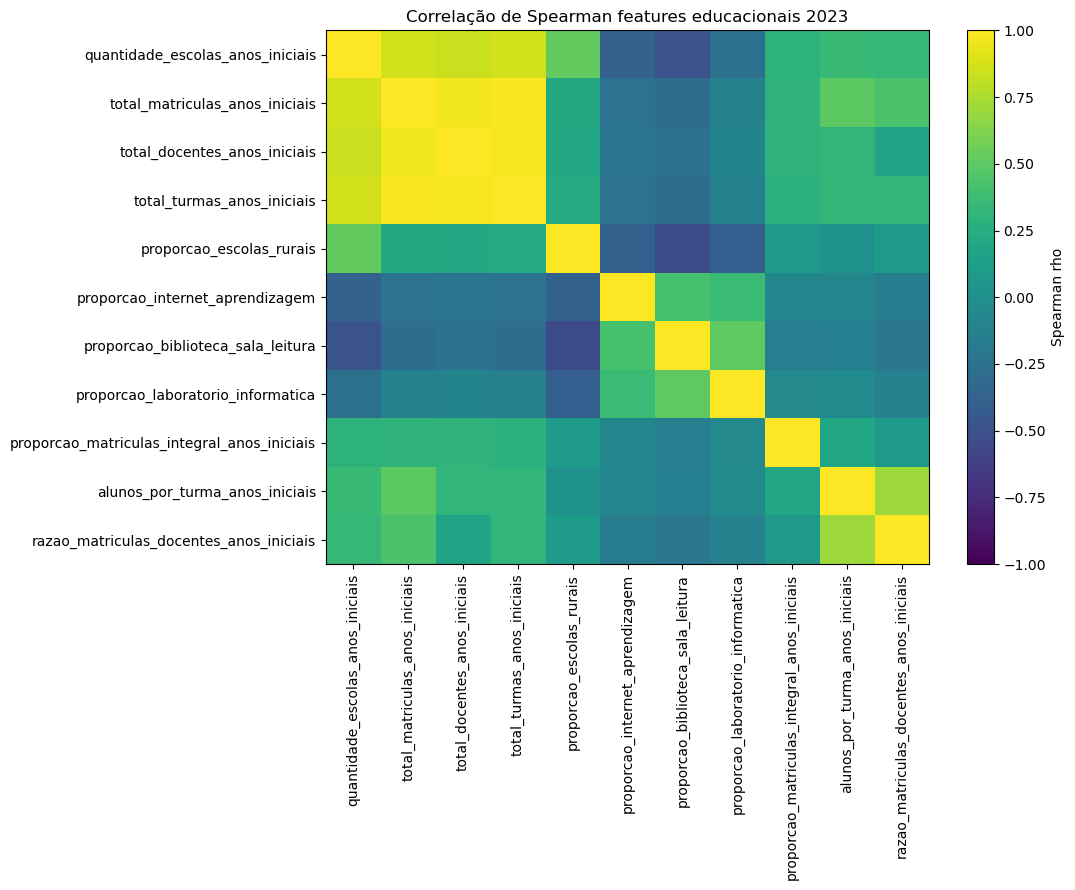

In [12]:
fig, ax = plt.subplots(
    figsize=(11, 9)
)

imagem = ax.imshow(
    corr_spearman.values,
    vmin=-1,
    vmax=1,
    aspect="auto",
)

ax.set_xticks(
    range(len(FEATURES_EDUCACIONAIS))
)
ax.set_yticks(
    range(len(FEATURES_EDUCACIONAIS))
)

ax.set_xticklabels(
    FEATURES_EDUCACIONAIS,
    rotation=90,
)
ax.set_yticklabels(
    FEATURES_EDUCACIONAIS,
)

ax.set_title(
    "Correlação de Spearman features educacionais 2023"
)

fig.colorbar(
    imagem,
    ax=ax,
    label="Spearman rho",
)

fig.tight_layout()

fig.savefig(
    IMAGES_PATH / "13_correlacao_spearman_educacional_2023.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()


In [13]:
pares = []

for i, feature_a in enumerate(
    FEATURES_EDUCACIONAIS
):
    for feature_b in FEATURES_EDUCACIONAIS[
        i + 1:
    ]:
        rho = corr_spearman.loc[
            feature_a,
            feature_b,
        ]

        pares.append(
            {
                "feature_a": feature_a,
                "feature_b": feature_b,
                "spearman_rho": rho,
                "abs_spearman_rho": abs(rho),
            }
        )

pares_correlacao = (
    pd.DataFrame(pares)
    .sort_values(
        "abs_spearman_rho",
        ascending=False,
    )
)

redundancias = pares_correlacao[
    pares_correlacao["abs_spearman_rho"]
    >= 0.80
].copy()

print("Pares com |rho| >= 0,80:")
display(redundancias)

pares_correlacao.to_csv(
    REPORTS_PATH / "eda_enrichment_2023_pares_correlacao.csv",
    index=False,
)

redundancias.to_csv(
    REPORTS_PATH / "eda_enrichment_2023_redundancias.csv",
    index=False,
)


Pares com |rho| >= 0,80:


,feature_a,feature_b,spearman_rho,abs_spearman_rho
11,total_matriculas_anos_iniciais,total_turmas_anos_iniciais,0.9772,0.9772
19,total_docentes_anos_iniciais,total_turmas_anos_iniciais,0.9742,0.9742
10,total_matriculas_anos_iniciais,total_docentes_anos_iniciais,0.9545,0.9545
2,quantidade_escolas_anos_iniciais,total_turmas_anos_iniciais,0.8629,0.8629
0,quantidade_escolas_anos_iniciais,total_matriculas_anos_iniciais,0.8602,0.8602
1,quantidade_escolas_anos_iniciais,total_docentes_anos_iniciais,0.8410,0.8410


## 7. Associação exploratória com alfabetização

A associação é medida de três formas:

- **Pearson no nível do aluno**: aproxima o sinal que o modelo recebe;
- **Spearman contexto × taxa de alfabetização**: verifica associação monotônica no
  nível município-rede;
- **gap entre grupos extremos**: divide os contextos em até quatro quantis e compara
  a taxa ponderada de alfabetização do grupo superior com a do inferior.

Essas métricas são exploratórias. Uma associação pequena não implica que a feature
seja inútil em modelos não lineares ou em interação com outras variáveis.


In [14]:
def resumo_quantis_target(
    contexto,
    feature,
):
    dados = contexto[
        [
            feature,
            "quantidade_alunos",
            "quantidade_alfabetizados",
        ]
    ].dropna().copy()

    if dados.empty:
        return (
            pd.DataFrame(),
            np.nan,
            0,
        )

    try:
        dados["grupo_quantile"] = pd.qcut(
            dados[feature],
            q=4,
            labels=False,
            duplicates="drop",
        )
    except ValueError:
        return (
            pd.DataFrame(),
            np.nan,
            0,
        )

    resumo = (
        dados.groupby(
            "grupo_quantile",
            observed=True,
            as_index=False,
        )
        .agg(
            contextos=(feature, "size"),
            quantidade_alunos=(
                "quantidade_alunos",
                "sum",
            ),
            alfabetizados=(
                "quantidade_alfabetizados",
                "sum",
            ),
            feature_min=(feature, "min"),
            feature_max=(feature, "max"),
        )
    )

    resumo["taxa_alfabetizacao"] = (
        resumo["alfabetizados"]
        / resumo["quantidade_alunos"]
    )

    if len(resumo) >= 2:
        gap_pp = (
            resumo.iloc[-1]["taxa_alfabetizacao"]
            - resumo.iloc[0]["taxa_alfabetizacao"]
        ) * 100
    else:
        gap_pp = np.nan

    return resumo, gap_pp, len(resumo)


associacoes = []
quantis_detalhes = []

for feature in FEATURES_EDUCACIONAIS:

    aluno_valido = df[
        [
            feature,
            "alfabetizado",
        ]
    ].dropna()

    corr_aluno = (
        aluno_valido[
            feature
        ]
        .corr(
            aluno_valido[
                "alfabetizado"
            ],
            method="pearson",
        )
    )

    contexto_valido = (
        df_contexto[
            [
                feature,
                "taxa_alfabetizacao",
            ]
        ]
        .dropna()
    )

    corr_contexto = (
        contexto_valido[
            feature
        ]
        .corr(
            contexto_valido[
                "taxa_alfabetizacao"
            ],
            method="spearman",
        )
    )

    resumo_q, gap_pp, n_grupos = (
        resumo_quantis_target(
            df_contexto,
            feature,
        )
    )

    associacoes.append(
        {
            "feature": feature,
            "pearson_aluno_target": corr_aluno,
            "spearman_contexto_taxa": corr_contexto,
            "gap_extremos_pp": gap_pp,
            "n_grupos_quantile": n_grupos,
        }
    )

    if not resumo_q.empty:
        resumo_q.insert(
            0,
            "feature",
            feature,
        )

        quantis_detalhes.append(
            resumo_q
        )


associacoes = pd.DataFrame(
    associacoes
)

associacoes["abs_pearson_aluno_target"] = (
    associacoes["pearson_aluno_target"]
    .abs()
)

associacoes["abs_spearman_contexto_taxa"] = (
    associacoes["spearman_contexto_taxa"]
    .abs()
)

associacoes = associacoes.sort_values(
    "abs_spearman_contexto_taxa",
    ascending=False,
)

display(associacoes)

associacoes.to_csv(
    REPORTS_PATH / "eda_enrichment_2023_associacoes_target.csv",
    index=False,
)

if quantis_detalhes:
    pd.concat(
        quantis_detalhes,
        ignore_index=True,
    ).to_csv(
        REPORTS_PATH / "eda_enrichment_2023_quantis_target.csv",
        index=False,
    )


,feature,pearson_aluno_target,spearman_contexto_taxa,gap_extremos_pp,n_grupos_quantile,abs_pearson_aluno_target,abs_spearman_contexto_taxa
6,proporcao_biblioteca_sala_leitura,0.0876,0.2834,11.3351,3,0.0876,0.2834
5,proporcao_internet_aprendizagem,0.0943,0.2619,10.8516,3,0.0943,0.2619
0,quantidade_escolas_anos_iniciais,-0.0219,-0.2615,-10.3915,4,0.0219,0.2615
10,razao_matriculas_docentes_anos_iniciais,-0.0834,-0.2581,-11.2864,4,0.0834,0.2581
1,total_matriculas_anos_iniciais,-0.0102,-0.2170,-9.4218,4,0.0102,0.2170
4,proporcao_escolas_rurais,-0.0483,-0.2123,-7.8691,3,0.0483,0.2123
7,proporcao_laboratorio_informatica,0.0565,0.2089,7.4694,3,0.0565,0.2089
3,total_turmas_anos_iniciais,-0.0104,-0.1960,-8.1562,4,0.0104,0.1960
9,alunos_por_turma_anos_iniciais,-0.0489,-0.1906,-7.2199,4,0.0489,0.1906
2,total_docentes_anos_iniciais,-0.0045,-0.1617,-6.3646,4,0.0045,0.1617


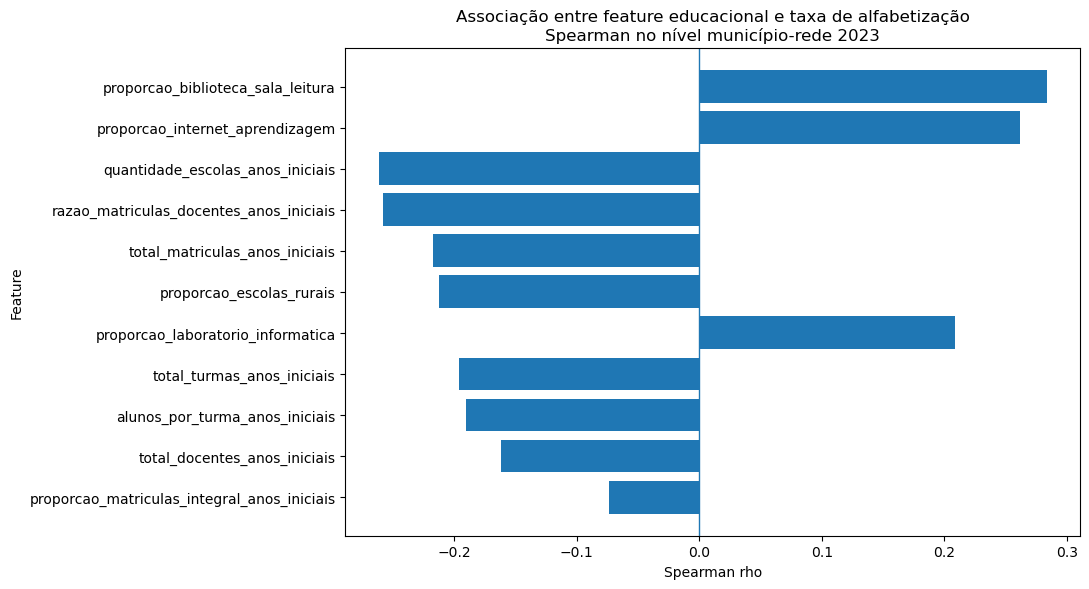

In [15]:
plot_assoc = (
    associacoes
    .sort_values(
        "abs_spearman_contexto_taxa",
        ascending=True,
    )
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.barh(
    plot_assoc["feature"],
    plot_assoc["spearman_contexto_taxa"],
)

ax.axvline(
    0,
    linewidth=1,
)

ax.set_title(
    "Associação entre feature educacional e taxa de alfabetização\n"
    "Spearman no nível município-rede 2023"
)

ax.set_xlabel("Spearman rho")
ax.set_ylabel("Feature")

fig.tight_layout()

fig.savefig(
    IMAGES_PATH / "14_associacao_target_educacional_2023.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()


## 8. Perfil por rede de ensino

Esta visão serve para verificar se determinadas features educacionais estão
capturando principalmente diferenças estruturais entre redes, em vez de variação
dentro das redes.

A interpretação deve ser cautelosa: diferenças de contexto não representam efeitos
causais da rede sobre a alfabetização.


In [16]:
aggs_rede = {
    "contextos": (
        "id_municipio",
        "size",
    ),
    "alunos": (
        "quantidade_alunos",
        "sum",
    ),
    "alfabetizados": (
        "quantidade_alfabetizados",
        "sum",
    ),
}

for feature in FEATURES_EDUCACIONAIS:
    aggs_rede[
        f"mediana__{feature}"
    ] = (
        feature,
        "median",
    )

perfil_rede = (
    df_contexto.groupby(
        "rede_nome",
        observed=True,
        as_index=False,
    )
    .agg(**aggs_rede)
)

perfil_rede[
    "taxa_alfabetizacao"
] = (
    perfil_rede["alfabetizados"]
    / perfil_rede["alunos"]
)

display(perfil_rede)

perfil_rede.to_csv(
    REPORTS_PATH / "eda_enrichment_2023_perfil_rede.csv",
    index=False,
)


,rede_nome,contextos,alunos,alfabetizados,mediana__quantidade_escolas_anos_iniciais,mediana__total_matriculas_anos_iniciais,mediana__total_docentes_anos_iniciais,mediana__total_turmas_anos_iniciais,mediana__proporcao_escolas_rurais,mediana__proporcao_internet_aprendizagem,mediana__proporcao_biblioteca_sala_leitura,mediana__proporcao_laboratorio_informatica,mediana__proporcao_matriculas_integral_anos_iniciais,mediana__alunos_por_turma_anos_iniciais,mediana__razao_matriculas_docentes_anos_iniciais,taxa_alfabetizacao
0,Estadual,1059,131522,80662,2.0000,273.0000,18.0000,13.0000,0.0000,1.0000,1.0000,0.8462,0.0061,20.7037,15.8571,0.6133
1,Municipal,4822,1371287,796765,7.0000,666.5000,41.0000,34.0000,0.5333,0.5909,0.5000,0.1667,0.0199,20.0000,16.4065,0.5810


## 9. Tabela de evidências para decisão do preprocessing

A tabela abaixo reúne evidências de distribuição, missingness, redundância e
associação com o target.

Ela **não elimina features automaticamente**.

A decisão final será tomada após revisar os resultados desta EDA e antes de alterar
o `preprocessor.py`.


In [17]:
evidencias = (
    descritivas[
        [
            "feature",
            "n",
            "n_unique",
            "skew_raw",
            "skew_log1p",
            "reducao_abs_skew_log1p",
            "candidata_log1p_distribuicao",
        ]
    ]
    .merge(
        missing[
            [
                "feature",
                "nulos_alunos",
                "pct_nulos_alunos",
                "nulos_contextos",
                "pct_nulos_contextos",
            ]
        ],
        on="feature",
        how="left",
    )
    .merge(
        associacoes[
            [
                "feature",
                "pearson_aluno_target",
                "spearman_contexto_taxa",
                "gap_extremos_pp",
                "n_grupos_quantile",
            ]
        ],
        on="feature",
        how="left",
    )
)

max_corr_outra = {}

for feature in FEATURES_EDUCACIONAIS:
    outros = (
        corr_spearman.loc[
            feature
        ]
        .drop(
            labels=[feature]
        )
        .abs()
    )

    max_corr_outra[
        feature
    ] = (
        outros.max()
        if not outros.empty
        else np.nan
    )

evidencias[
    "max_abs_spearman_com_outra_feature"
] = (
    evidencias["feature"]
    .map(max_corr_outra)
)

evidencias[
    "alerta_redundancia_080"
] = (
    evidencias[
        "max_abs_spearman_com_outra_feature"
    ]
    >= 0.80
)

evidencias = evidencias.sort_values(
    [
        "alerta_redundancia_080",
        "max_abs_spearman_com_outra_feature",
    ],
    ascending=[
        False,
        False,
    ],
)

display(evidencias)

evidencias.to_csv(
    REPORTS_PATH / "eda_enrichment_2023_evidencias_preprocessing.csv",
    index=False,
)


,feature,n,n_unique,skew_raw,skew_log1p,reducao_abs_skew_log1p,candidata_log1p_distribuicao,nulos_alunos,pct_nulos_alunos,nulos_contextos,pct_nulos_contextos,pearson_aluno_target,spearman_contexto_taxa,gap_extremos_pp,n_grupos_quantile,max_abs_spearman_com_outra_feature,alerta_redundancia_080
1,total_matriculas_anos_iniciais,5877,2368,26.2937,0.5050,25.7887,True,75,0.0050,4,0.0680,-0.0102,-0.2170,-9.4218,4,0.9772,True
3,total_turmas_anos_iniciais,5877,431,22.5876,0.6265,21.9611,True,75,0.0050,4,0.0680,-0.0104,-0.1960,-8.1562,4,0.9772,True
2,total_docentes_anos_iniciais,5877,493,22.5881,0.6301,21.9579,True,75,0.0050,4,0.0680,-0.0045,-0.1617,-6.3646,4,0.9742,True
0,quantidade_escolas_anos_iniciais,5877,137,11.0782,0.6206,10.4576,True,75,0.0050,4,0.0680,-0.0219,-0.2615,-10.3915,4,0.8629,True
9,alunos_por_turma_anos_iniciais,5875,4013,1.1897,-0.5478,0.6419,True,86,0.0057,6,0.1020,-0.0489,-0.1906,-7.2199,4,0.7107,False
10,razao_matriculas_docentes_anos_iniciais,5875,4461,0.9410,-0.2456,0.6954,False,86,0.0057,6,0.1020,-0.0834,-0.2581,-11.2864,4,0.7107,False
4,proporcao_escolas_rurais,5877,497,-0.0887,-0.2839,-0.1952,False,75,0.0050,4,0.0680,-0.0483,-0.2123,-7.8691,3,0.5483,False
6,proporcao_biblioteca_sala_leitura,5877,784,-0.2067,-0.4121,-0.2053,False,75,0.0050,4,0.0680,0.0876,0.2834,11.3351,3,0.5483,False
7,proporcao_laboratorio_informatica,5877,644,0.5219,0.3470,0.1749,False,75,0.0050,4,0.0680,0.0565,0.2089,7.4694,3,0.5037,False
5,proporcao_internet_aprendizagem,5877,812,-0.3632,-0.5705,-0.2072,False,75,0.0050,4,0.0680,0.0943,0.2619,10.8516,3,0.4176,False


## 10. Checklist final da EDA complementar

Após executar o notebook, revisar principalmente:

1. `eda_enrichment_2023_descritivas.csv`
   - assimetria bruta e após `log1p`;
   - P95/P99/máximos.

2. `eda_enrichment_2023_redundancias.csv`
   - pares com `|Spearman| >= 0,80`.

3. `eda_enrichment_2023_associacoes_target.csv`
   - associação no nível do aluno;
   - associação no nível município-rede;
   - diferença de alfabetização entre grupos extremos.

4. `eda_enrichment_2023_evidencias_preprocessing.csv`
   - consolidação usada para decidir o novo preprocessing.

### Importante

Nenhuma decisão deve ser baseada em 2024 nesta etapa.

O próximo passo, após a revisão destes resultados, será definir explicitamente:

- features educacionais que entram no conjunto enriquecido;
- features eventualmente removidas por redundância;
- variáveis com `log1p`;
- variáveis apenas imputadas/escaladas;
- estrutura final do `preprocessor.py`.


In [18]:
print("=" * 72)
print("EDA COMPLEMENTAR 2023 CONCLUÍDA")
print("=" * 72)

print(
    f"Contextos município-rede analisados: "
    f"{len(df_contexto):,}"
)

print(
    f"Features educacionais analisadas: "
    f"{len(FEATURES_EDUCACIONAIS)}"
)

print(
    f"Pares com |Spearman| >= 0,80: "
    f"{len(redundancias)}"
)

print(
    "\nArquivos principais gerados:"
)

for arquivo in [
    "eda_enrichment_2023_missingness.csv",
    "eda_enrichment_2023_descritivas.csv",
    "eda_enrichment_2023_correlacao_spearman.csv",
    "eda_enrichment_2023_redundancias.csv",
    "eda_enrichment_2023_associacoes_target.csv",
    "eda_enrichment_2023_quantis_target.csv",
    "eda_enrichment_2023_perfil_rede.csv",
    "eda_enrichment_2023_evidencias_preprocessing.csv",
]:
    caminho = REPORTS_PATH / arquivo

    if caminho.exists():
        print(f"  ✓ {caminho.relative_to(PROJECT_ROOT)}")

print(
    "\nNão utilize resultados de 2024 para decisões nesta etapa."
)


EDA COMPLEMENTAR 2023 CONCLUÍDA
Contextos município-rede analisados: 5,881
Features educacionais analisadas: 11
Pares com |Spearman| >= 0,80: 6

Arquivos principais gerados:
  ✓ reports\metrics\eda_enrichment_2023_missingness.csv
  ✓ reports\metrics\eda_enrichment_2023_descritivas.csv
  ✓ reports\metrics\eda_enrichment_2023_correlacao_spearman.csv
  ✓ reports\metrics\eda_enrichment_2023_redundancias.csv
  ✓ reports\metrics\eda_enrichment_2023_associacoes_target.csv
  ✓ reports\metrics\eda_enrichment_2023_quantis_target.csv
  ✓ reports\metrics\eda_enrichment_2023_perfil_rede.csv
  ✓ reports\metrics\eda_enrichment_2023_evidencias_preprocessing.csv

Não utilize resultados de 2024 para decisões nesta etapa.
